Sales Data Analysis - EDA

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path.cwd()

df = pd.read_csv(BASE / "sales_dataset.csv")
df.head()

,Order_ID,Order_Date,Customer_Name,City,Region,Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Net_Sales,Profit,Sales_Channel
0,ORD10001,2025-11-15,Kavya Singh,Jaipur,North,Furniture,Office Chair,3,18090.0,8.27,53764.42,14494.65,Offline
1,ORD10002,2025-02-11,Nitin Joshi,Bhopal,Central,Grocery,Coffee,10,570.0,4.43,5447.49,773.49,Offline
2,ORD10003,2025-06-28,Arjun Nair,Delhi,North,Clothing,Jacket,3,2790.0,11.25,7428.38,2824.87,Offline
3,ORD10004,2025-05-28,Manish Agarwal,Gurugram,North,Furniture,Office Chair,2,12700.0,9.95,21729.06,5561.96,Offline
4,ORD10005,2025-02-16,Riya Kapoor,Bengaluru,South,Electronics,Tablet,4,22720.0,15.80,76520.96,5634.56,Online


1. Buisness Problem

Understand sales and profit performance across products ,categories, regions, discounts
ands channels;identify data quality issues and actionable opportunities.

2. Dataset Understanding

In [13]:
print(df.shape); display(df.head()); display(df.dtypes.to_frame("dtype")); display(df.describe(include="all").T)

(1000, 13)


,Order_ID,Order_Date,Customer_Name,City,Region,Category,Product_Name,Quantity,Unit_Price,Discount_Percent,Net_Sales,Profit,Sales_Channel
0,ORD10001,2025-11-15,Kavya Singh,Jaipur,North,Furniture,Office Chair,3,18090.0,8.27,53764.42,14494.65,Offline
1,ORD10002,2025-02-11,Nitin Joshi,Bhopal,Central,Grocery,Coffee,10,570.0,4.43,5447.49,773.49,Offline
2,ORD10003,2025-06-28,Arjun Nair,Delhi,North,Clothing,Jacket,3,2790.0,11.25,7428.38,2824.87,Offline
3,ORD10004,2025-05-28,Manish Agarwal,Gurugram,North,Furniture,Office Chair,2,12700.0,9.95,21729.06,5561.96,Offline
4,ORD10005,2025-02-16,Riya Kapoor,Bengaluru,South,Electronics,Tablet,4,22720.0,15.80,76520.96,5634.56,Online


,dtype
Order_ID,str
Order_Date,str
Customer_Name,str
City,str
Region,str
Category,str
Product_Name,str
Quantity,int64
Unit_Price,float64
Discount_Percent,float64


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Order_ID,1000,1000,ORD10001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,1000,344,2025-11-26,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Name,1000,20,Riya Kapoor,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,1000,16,Jaipur,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,1000,5,North,315,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Category,1000,5,Furniture,228,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Name,1000,20,Study Table,70,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,1000.0,NaN,NaN,NaN,3.315,2.049384,1.0,2.0,3.0,4.0,10.0
Unit_Price,1000.0,NaN,NaN,NaN,16704.47,20344.206932,130.0,2147.5,7750.0,21452.5,89390.0
Discount_Percent,1000.0,NaN,NaN,NaN,10.30344,4.090091,0.0,7.605,10.33,13.0725,24.44


3. Data Exploration

In [20]:
for c in df.columns:
    print("\n---",c,"---"); print("Unique:",df[c].nunique(dropna=True)); print(df[c].value_counts(dropna=False).head(10))


--- Order_ID ---
Unique: 1000
Order_ID
ORD10001    1
ORD10002    1
ORD10003    1
ORD10004    1
ORD10005    1
ORD10006    1
ORD10007    1
ORD10008    1
ORD10009    1
ORD10010    1
Name: count, dtype: int64

--- Order_Date ---
Unique: 344
Order_Date
2025-11-26    8
2025-10-08    7
2025-07-14    7
2025-03-28    7
2025-04-02    7
2025-09-19    7
2025-09-15    7
2025-06-20    7
2025-11-15    6
2025-05-13    6
Name: count, dtype: int64

--- Customer_Name ---
Unique: 20
Customer_Name
Riya Kapoor       68
Aarav Sharma      58
Neha Gupta        58
Kavya Singh       56
Vikram Mehta      56
Priya Verma       54
Amit Kumar        53
Nitin Joshi       50
Manish Agarwal    50
Shreya Das        49
Name: count, dtype: int64

--- City ---
Unique: 16
City
Jaipur       73
Delhi        71
Ahmedabad    71
Bengaluru    70
Hyderabad    68
Chennai      65
Pune         65
Surat        64
Kolkata      63
Noida        62
Name: count, dtype: int64

--- Region ---
Unique: 5
Region
North      315
West       253
So

4. Data Cleaning

In [26]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(r"[^a-z0-9]+", "_", regex=True)
    .str.strip("_")
)
# Clean text columns
for c in df.select_dtypes(include=["object", "string"]).columns:
    df[c] = df[c].astype("string").str.strip()
# Convert date
if "order_date" in df.columns:
    df["order_date"] = pd.to_datetime(
        df["order_date"],
        errors="coerce"
    )

# Convert numeric columns
numeric_cols = [
    "quantity",
    "unit_price",
    "discount_percent",
    "net_sales",
    "profit"
]

for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

5. Missing Value Analysis 

In [28]:
missing=pd.DataFrame({"count":df.isna().sum(),"percent":(df.isna().mean()*100).round(2)})
display(missing[missing["count"]>0])

,count,percent


6.Duplicate Detection

In [30]:
print("Duplicate rows:",df.duplicated().sum()); df=df.drop_duplicates().reset_index(drop=True)

Duplicate rows: 0


7. Date Type Handling

In [32]:
if "order_date" in df:
    df["order_year"] = df.order_date.dt.year; df["order_month"]=df.order_date.dt.month
    df["order_quarter"]="Q"+df.order_date.dt.quarter.astype(str)
display(df.dtypes.to_frame("dtype"))    

,dtype
order_id,string
order_date,datetime64[us]
customer_name,string
city,string
region,string
category,string
product_name,string
quantity,int64
unit_price,float64
discount_percent,float64


8.Outlier Analysis

In [33]:
rows=[]
for c in df.select_dtypes(np.number):
    q1,q3=df[c].quantile([.25,.75]); iqr=q3-q1; lo,hi=q1=1.5*iqr,q3+1.5*iqr
    n=((df[c]<lo)|(df[c]>hi)).sum(); rows.append([c,q1,q3,lo,hi,int(n),round(n/len(df)*100,2)])
display(pd.DataFrame(rows,columns=["column","q1","q3","lower","upper","outlier_count","Outlier_percent"]))    

,column,q1,q3,lower,upper,outlier_count,Outlier_percent
0,quantity,"(3.0, 7.0)",4.0000,3.00000,7.00000,451,45.1
1,unit_price,"(28957.5, 50410.0)",21452.5000,28957.50000,50410.00000,909,90.9
2,discount_percent,"(8.201249999999998, 21.27375)",13.0725,8.20125,21.27375,288,28.8
3,net_sales,"(66576.62625, 117375.57625000001)",50798.9500,66576.62625,117375.57625,908,90.8
4,profit,"(12483.63375, 22043.85625)",9560.2225,12483.63375,22043.85625,893,89.3
5,order_year,"(0.0, 2025.0)",2025.0000,0.00000,2025.00000,0,0.0
6,order_month,"(7.5, 16.5)",9.0000,7.50000,16.50000,578,57.8


9. Univariate Analysis

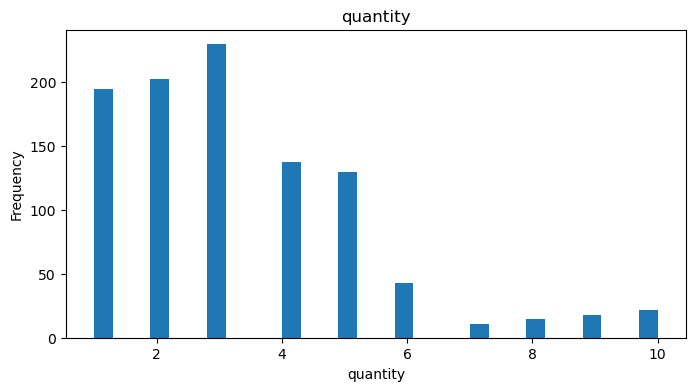

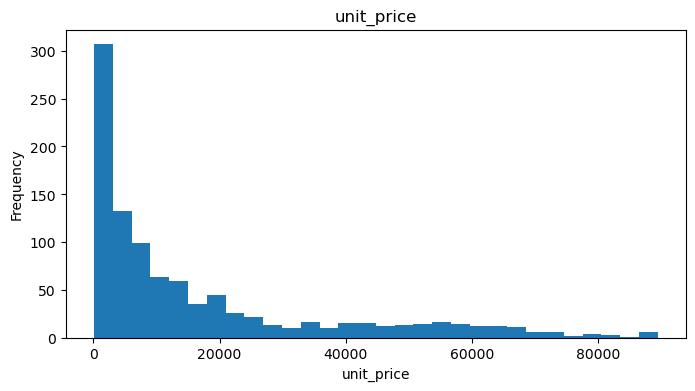

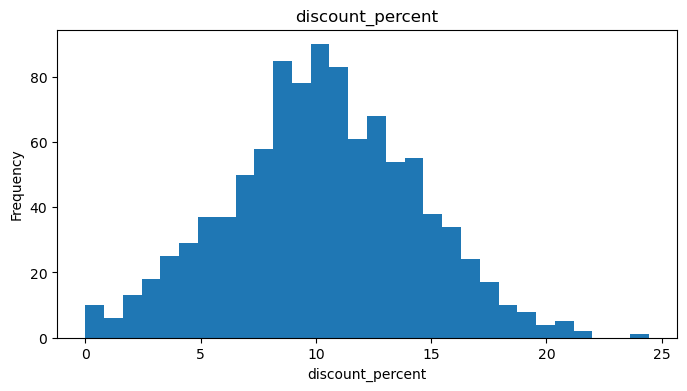

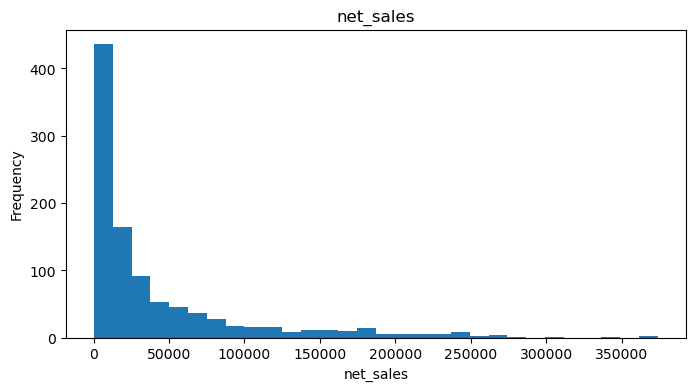

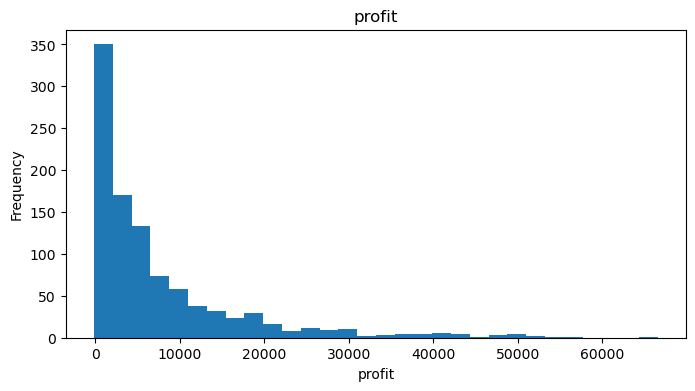

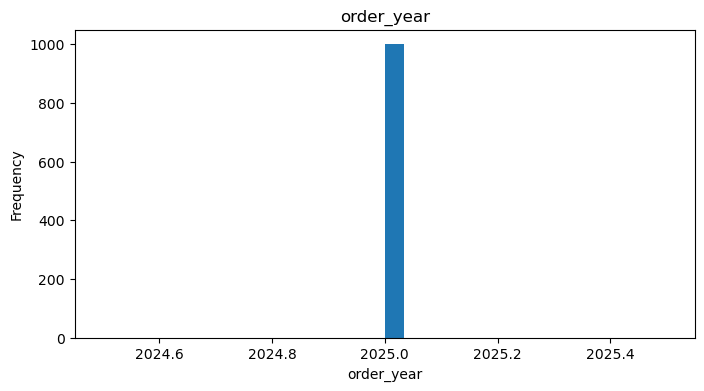

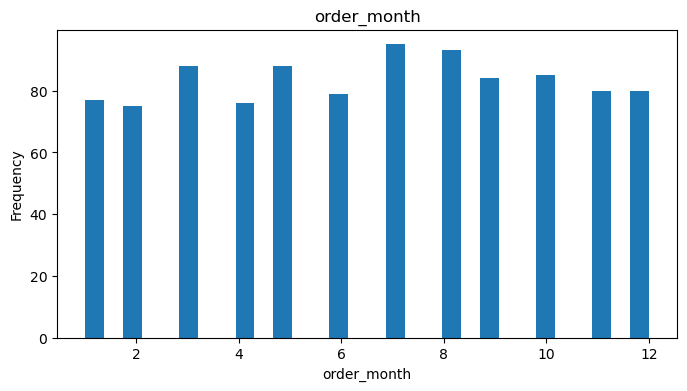

In [36]:
for c in df.select_dtypes(np.number):
    plt.figure(figsize=(8,4)); plt.hist(df[c].dropna(),bins=30); plt.title(c); plt.xlabel(c); plt.ylabel("Frequency");plt.show()

10. Bivariate Analysis

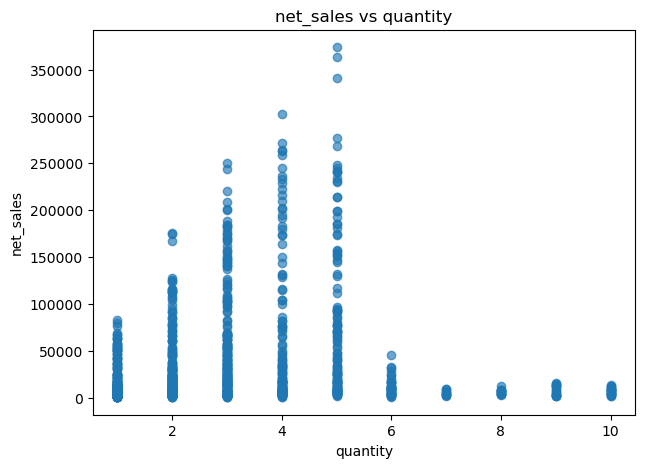

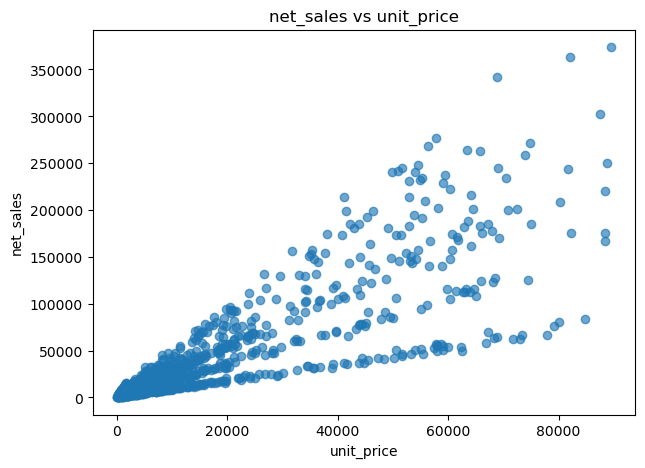

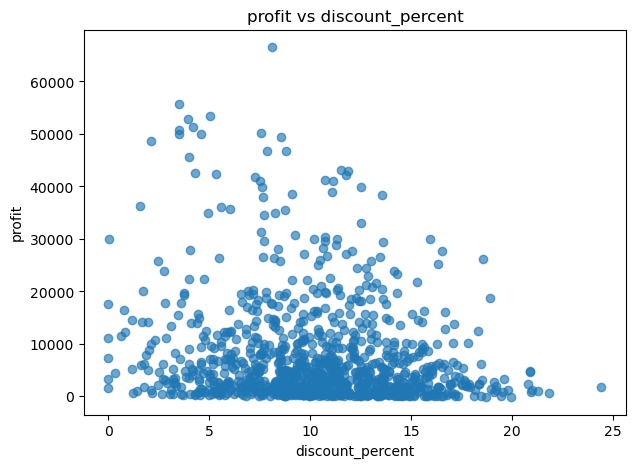

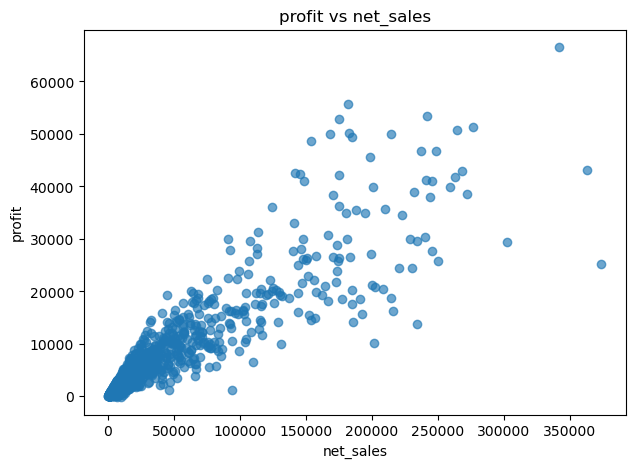

,sum,mean,count
category,,,
Furniture,2296582.08,10072.728421,228
Electronics,2192004.74,10905.496219,201
Home Appliances,2170188.34,10690.582956,203
Clothing,768033.67,3692.469567,208
Grocery,63335.81,395.848813,160


,sum,mean,count
region,,,
North,2475026.16,7857.225905,315
West,1888191.04,7463.205692,253
South,1593404.30,7849.282266,203
East,849984.66,7142.728235,119
Central,683538.48,6213.986182,110


,sum,mean,count
sales_channel,,,
Online,5009081.07,7566.587719,662
Offline,2481063.57,7340.424763,338


,sum,mean,count
product_name,,,
Sofa,1254394.25,24122.966346,52
Washing Machine,891864.98,18201.326122,49
Laptop,891440.16,18966.811915,47
Refrigerator,751835.18,20884.310556,36
Smartphone,710745.63,14505.012857,49
Study Table,489655.48,6995.078286,70
Tablet,408231.48,9956.865366,41
Microwave,398390.76,6989.311579,57
Office Chair,357419.37,6162.402931,58


In [37]:
for x,y in [("quantity","net_sales"),("unit_price","net_sales"),("discount_percent","profit"),("net_sales","profit")]:
    if x in df and y in df:
        plt.figure(figsize=(7,5)); plt.scatter(df[x],df[y],alpha=.65); plt.xlabel(x); plt.ylabel(y); plt.title(f"{y} vs {x}"); plt.show()
for c in ["category","region","sales_channel","product_name"]:
    if c in df and "profit" in df: display(df.groupby(c).profit.agg(["sum","mean","count"]).sort_values("sum",ascending=False))

11. Multivariate Analysis

In [38]:
dims=[c for c in ["region","category","sales_channel"]if c in df]
if len(dims)>=2: display(df.groupby(dims)[["net_sales","profit"]].sum().sort_values("profit",ascending=False).head(20))

net_sales     profit
region  category        sales_channel                       
North   Home Appliances Online         2884697.06  526352.67
        Furniture       Online         2022714.95  497985.52
        Electronics     Online         4109765.28  490347.05
West    Home Appliances Online         2572709.89  429275.83
South   Electronics     Online         2866274.93  383855.61
        Furniture       Online         1420905.39  373345.64
West    Home Appliances Offline        1774669.25  337196.09
        Electronics     Online         2226956.56  307341.08
North   Electronics     Offline        2210355.57  273408.94
West    Furniture       Online          896175.91  236849.53
North   Furniture       Offline         861127.17  230626.27
East    Furniture       Online          830418.28  229332.14
South   Home Appliances Online         1340222.16  223824.86
Central Furniture       Online          783932.87  206960.35
South   Furniture       Offline         847635.99  206434.88
North   Clothing        Online          485844.66  189702.39
        Home Appliances Offline        1255137.69  188251.36
West    Electronics     Offline        1475532.17  180725.47
        Furniture       Offline         640157.27  160866.83
        Clothing        Online          396221.83  154738.28